## Lab Assignment - 4 End-to-End Machine Learning Project


###  Airbnb Price Prediction

In [31]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

warnings.filterwarnings("ignore")


In [32]:
DATA_PATH = "AB_NYC_2019.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Change DATA_PATH to the location of your Airbnb CSV file."
    )

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("ORIGINAL DATASET")
print("=" * 70)
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


ORIGINAL DATASET
Shape: (48895, 16)

Columns:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


In [33]:
# Remove exact duplicate rows
duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

df = df.drop_duplicates().copy()


# ------------------------------------------------------------
# Remove irrelevant identifier / free-text columns
# ------------------------------------------------------------

columns_to_drop = [
    "id",
    "host_id",
    "name",
    "host_name",
    "last_review"
]

# Keep last_review temporarily because we use it to create
# has_review, year and month.
columns_to_drop_without_date = [
    "id",
    "host_id",
    "name",
    "host_name"
]

df = df.drop(
    columns=[
        c for c in columns_to_drop_without_date
        if c in df.columns
    ],
    errors="ignore"
)


Duplicate rows: 0


In [34]:
if "last_review" in df.columns:

    df["last_review"] = pd.to_datetime(
        df["last_review"],
        errors="coerce"
    )

    # A listing has a review if last_review is available
    df["has_review"] = (
        df["last_review"].notna()
    ).astype(int)

    # These are optional exploratory features.
    # They are NOT used in the final feature set because
    # they showed very weak relationship with price.
    df["last_review_year"] = (
        df["last_review"].dt.year
    )

    df["last_review_month"] = (
        df["last_review"].dt.month
    )

else:

    df["has_review"] = 0

In [35]:
df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)

# Remove missing and zero/negative prices
before_price_cleaning = len(df)

df = df[
    df["price"].notna() &
    (df["price"] > 0)
].copy()

print("\nRows removed because of invalid price:",
      before_price_cleaning - len(df))


# ------------------------------------------------------------
# IMPORTANT:
# Calculate the percentile ONCE.
# Do not rerun this filtering cell on an already filtered df.
# ------------------------------------------------------------

price_upper_limit = df["price"].quantile(0.99)

print("99th percentile price:", price_upper_limit)

before_outlier = len(df)

df = df[
    df["price"] <= price_upper_limit
].copy()

print(
    "Rows removed as extreme price outliers:",
    before_outlier - len(df)
)

print("Maximum price after treatment:",
      df["price"].max())


Rows removed because of invalid price: 11
99th percentile price: 799.0
Rows removed as extreme price outliers: 474
Maximum price after treatment: 799


In [36]:
numeric_raw_columns = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

for col in numeric_raw_columns:

    if col in df.columns:

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )


# Remove impossible negative values.
# Missing values are NOT manually filled here;
# the modeling pipeline handles them using median imputation.

for col in [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]:

    if col in df.columns:

        df.loc[
            df[col] < 0,
            col
        ] = np.nan


# Availability must be between 0 and 365
if "availability_365" in df.columns:

    df["availability_365"] = df[
        "availability_365"
    ].clip(
        lower=0,
        upper=365
    )

In [37]:
log_source_columns = [
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count"
]

for col in log_source_columns:

    if col not in df.columns:
        raise ValueError(
            f"Required column missing: {col}"
        )

    # Temporary fill only for creating the log feature.
    # The final raw feature is not used in the model.
    values = df[col].fillna(0).clip(lower=0)

    df[
        "log_" + col
    ] = np.log1p(values)


# ------------------------------------------------------------
# Availability ratio
# ------------------------------------------------------------

if "availability_365" in df.columns:

    df["availability_ratio"] = (
        df["availability_365"] / 365.0
    )


# ------------------------------------------------------------
# Distance from approximate NYC centre
# ------------------------------------------------------------

if (
    "latitude" in df.columns
    and
    "longitude" in df.columns
):

    reference_lat = 40.7128
    reference_lon = -74.0060

    df["distance_from_center"] = np.sqrt(
        (df["latitude"] - reference_lat) ** 2
        +
        (df["longitude"] - reference_lon) ** 2
    )


# ------------------------------------------------------------
# Neighbourhood × room type interaction
# ------------------------------------------------------------

if (
    "neighbourhood_group" in df.columns
    and
    "room_type" in df.columns
):

    df["neighbourhood_room"] = (
        df["neighbourhood_group"].astype(str)
        + "_"
        + df["room_type"].astype(str)
    )

In [38]:
features = [

    # Location
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "distance_from_center",

    # Room information
    "room_type",
    "neighbourhood_room",

    # Skewed numerical variables after log transformation
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",

    # Availability
    "availability_ratio",

    # Review information
    "has_review"
]

target = "price"


missing_features = [
    col
    for col in features
    if col not in df.columns
]

if missing_features:

    raise ValueError(
        "The following selected features are missing:\n"
        + str(missing_features)
    )

X = df[features].copy()
y = df[target].copy()

print("\n" + "=" * 70)
print("FINAL MODELING DATA")
print("=" * 70)

print("Number of observations:", len(X))
print("Number of features:", len(features))

print("\nSelected features:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")



FINAL MODELING DATA
Number of observations: 48410
Number of features: 13

Selected features:
1. neighbourhood_group
2. neighbourhood
3. latitude
4. longitude
5. distance_from_center
6. room_type
7. neighbourhood_room
8. log_minimum_nights
9. log_number_of_reviews
10. log_reviews_per_month
11. log_calculated_host_listings_count
12. availability_ratio
13. has_review


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 9. DEFINE FEATURE TYPES
# ============================================================

categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type",
    "neighbourhood_room"
]

numerical_features = [
    "latitude",
    "longitude",
    "distance_from_center",
    "log_minimum_nights",
    "log_number_of_reviews",
    "log_reviews_per_month",
    "log_calculated_host_listings_count",
    "availability_ratio",
    "has_review"
]



Training samples: 38728
Testing samples : 9682


In [40]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)



In [41]:
target_transformer = FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    validate=False
)


In [42]:
models = {

    "Ridge Regression": Ridge(
        alpha=10.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
}


model_pipelines = {}

for name, model in models.items():

    base_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    model_pipelines[name] = (
        TransformedTargetRegressor(
            regressor=base_pipeline,
            transformer=target_transformer
        )
    )


In [43]:
results = []

for name, model in model_pipelines.items():

    print("\nTraining:", name)

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_mae = mean_absolute_error(
        y_train,
        train_pred
    )

    test_mae = mean_absolute_error(
        y_test,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_pred
        )
    )

    train_r2 = r2_score(
        y_train,
        train_pred
    )

    test_r2 = r2_score(
        y_test,
        test_pred
    )

    results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })


results_df = pd.DataFrame(
    results
).sort_values(
    by="Test RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("BASELINE MODEL COMPARISON")
print("=" * 70)

print(results_df.to_string(index=False))



Training: Ridge Regression

Training: Random Forest

Training: Extra Trees

BASELINE MODEL COMPARISON
           Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
   Random Forest  41.770562 44.388126   75.646160  78.756182  0.467282 0.430015
Ridge Regression  45.330913 45.741791   80.053658  80.039674  0.403396 0.411285
     Extra Trees  45.065630 46.265076   80.935553  81.987333  0.390179 0.382286


In [44]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in model_pipelines.items():

    print("\nCross-validating:", name)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean()
    })


cv_results_df = pd.DataFrame(
    cv_results
).sort_values(
    by="CV RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)

print(cv_results_df.to_string(index=False))


Cross-validating: Ridge Regression

Cross-validating: Random Forest

Cross-validating: Extra Trees

5-FOLD CROSS-VALIDATION
           Model    CV MAE   CV RMSE    CV R2
   Random Forest 44.368535 79.435203 0.412485
Ridge Regression 45.485954 80.248326 0.400420
     Extra Trees 45.939221 82.061425 0.373019


In [45]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    transformer=target_transformer
)


param_distributions = {

    "regressor__model__n_estimators": [
        100,
        150,200
        
    ],

    "regressor__model__max_depth": [
        10,
        15,
        20,
        None
    ],

    "regressor__model__min_samples_split": [
        2,
        5,
        10
    ],

    "regressor__model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "regressor__model__max_features": [
        "sqrt",
        "log2",
        0.5
    ]
}


rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print("\n" + "=" * 70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

rf_search.fit(
    X_train,
    y_train
)


print("\nBest parameters:")

for parameter, value in rf_search.best_params_.items():
    print(
        f"{parameter}: {value}"
    )


print(
    "\nBest CV RMSE:",
    -rf_search.best_score_
)


RANDOM FOREST HYPERPARAMETER TUNING
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters:
regressor__model__n_estimators: 100
regressor__model__min_samples_split: 5
regressor__model__min_samples_leaf: 1
regressor__model__max_features: 0.5
regressor__model__max_depth: 20

Best CV RMSE: 74.30442662934973


In [46]:
final_model = rf_search.best_estimator_

final_train_pred = final_model.predict(
    X_train
)

final_test_pred = final_model.predict(
    X_test
)


final_train_mae = mean_absolute_error(
    y_train,
    final_train_pred
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)


final_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        final_train_pred
    )
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)


final_train_r2 = r2_score(
    y_train,
    final_train_pred
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)


print("\n" + "=" * 70)
print("FINAL TUNED RANDOM FOREST")
print("=" * 70)

print(
    f"Train MAE  : ${final_train_mae:.2f}"
)

print(
    f"Test MAE   : ${final_test_mae:.2f}"
)

print(
    f"Train RMSE : ${final_train_rmse:.2f}"
)

print(
    f"Test RMSE  : ${final_test_rmse:.2f}"
)

print(
    f"Train R2   : {final_train_r2:.4f}"
)

print(
    f"Test R2    : {final_test_r2:.4f}"
)



FINAL TUNED RANDOM FOREST
Train MAE  : $25.52
Test MAE   : $41.87
Train RMSE : $48.45
Test RMSE  : $72.75
Train R2   : 0.7815
Test R2    : 0.5137


In [47]:
r2_gap = (
    final_train_r2
    -
    final_test_r2
)


print("\n" + "=" * 70)
print("OVERFITTING CHECK")
print("=" * 70)

print(
    f"Train R2 : {final_train_r2:.4f}"
)

print(
    f"Test R2  : {final_test_r2:.4f}"
)

print(
    f"R2 gap   : {r2_gap:.4f}"
)


if r2_gap > 0.20:

    print(
        "Result: Moderate/significant overfitting may be present."
    )

elif r2_gap > 0.10:

    print(
        "Result: Some overfitting may be present."
    )

else:

    print(
        "Result: No major overfitting detected."
    )



OVERFITTING CHECK
Train R2 : 0.7815
Test R2  : 0.5137
R2 gap   : 0.2678
Result: Moderate/significant overfitting may be present.


In [48]:
final_comparison = results_df.copy()

tuned_row = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Train MAE": final_train_mae,
    "Test MAE": final_test_mae,
    "Train RMSE": final_train_rmse,
    "Test RMSE": final_test_rmse,
    "Train R2": final_train_r2,
    "Test R2": final_test_r2
}])


final_comparison = pd.concat(
    [
        final_comparison,
        tuned_row
    ],
    ignore_index=True
)


final_comparison = final_comparison.sort_values(
    by="Test RMSE"
).reset_index(drop=True)


print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(
    final_comparison.to_string(index=False)
)


best_model_name = (
    final_comparison.iloc[0]["Model"]
)

print(
    "\nBest model based on test RMSE:",
    best_model_name
)



FINAL MODEL COMPARISON
              Model  Train MAE  Test MAE  Train RMSE  Test RMSE  Train R2  Test R2
Tuned Random Forest  25.523518 41.872143   48.450934  72.748528  0.781461 0.513657
      Random Forest  41.770562 44.388126   75.646160  78.756182  0.467282 0.430015
   Ridge Regression  45.330913 45.741791   80.053658  80.039674  0.403396 0.411285
        Extra Trees  45.065630 46.265076   80.935553  81.987333  0.390179 0.382286

Best model based on test RMSE: Tuned Random Forest


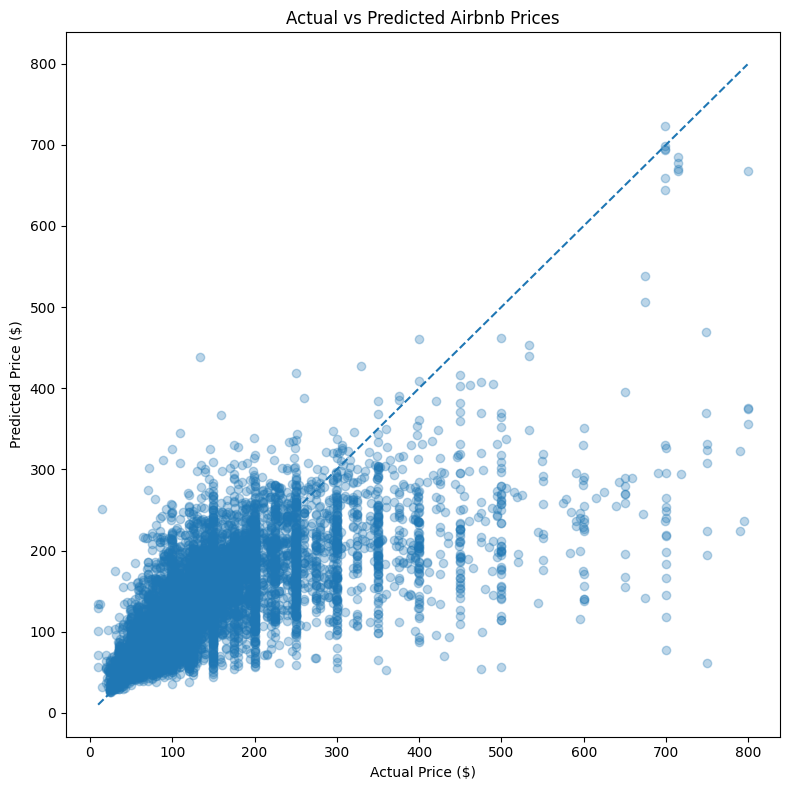

In [49]:
plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.3
)

minimum_value = min(
    y_test.min(),
    final_test_pred.min()
)

maximum_value = max(
    y_test.max(),
    final_test_pred.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--"
)

plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual vs Predicted Airbnb Prices")
plt.tight_layout()
plt.show()


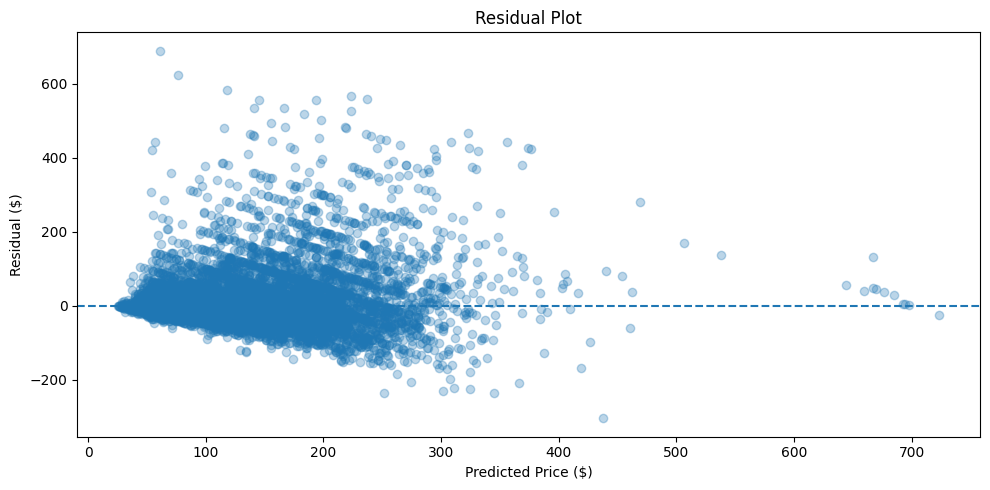

In [50]:
residuals = (
    y_test -
    final_test_pred
)

plt.figure(
    figsize=(10, 5)
)

plt.scatter(
    final_test_pred,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual ($)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


In [51]:
MODEL_PATH = "airbnb_price_prediction_final.pkl"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(
    f"Saved to: {MODEL_PATH}"
)



MODEL SAVED
Saved to: airbnb_price_prediction_final.pkl


In [52]:
final_comparison.to_csv(
    "airbnb_model_comparison.csv",
    index=False
)


pd.DataFrame({
    "Metric": [
        "Test MAE",
        "Test RMSE",
        "Test R2",
        "Train R2",
        "R2 Gap"
    ],
    "Value": [
        final_test_mae,
        final_test_rmse,
        final_test_r2,
        final_train_r2,
        r2_gap
    ]
}).to_csv(
    "airbnb_final_metrics.csv",
    index=False
)


pd.DataFrame({
    "Actual_Price": y_test.values,
    "Predicted_Price": final_test_pred
}).assign(
    Absolute_Error=lambda x:
        abs(
            x["Actual_Price"]
            -
            x["Predicted_Price"]
        )
).to_csv(
    "airbnb_test_predictions.csv",
    index=False
)


In [53]:
# Save and reload the fitted model pipeline
joblib.dump(rf_search.best_estimator_, MODEL_PATH, compress=3)
loaded_model = joblib.load(MODEL_PATH)

print("\nPredictions from the saved model:")
for p in loaded_model.predict(X_test.iloc[:5]):
    print(f"${p:.2f}")

print("\n" + "=" * 70 + "\nTASK 1 + TASK 2 COMPLETED\n" + "=" * 70)
print(f"Final model: {best_model_name}")
print(f"Test MAE   : ${final_test_mae:.2f}")
print(f"Test RMSE  : ${final_test_rmse:.2f}")
print(f"Test R2    : {final_test_r2:.4f}")
print(f"Model file : {MODEL_PATH}")


Predictions from the saved model:
$119.66
$184.93
$60.16
$53.77
$35.88

TASK 1 + TASK 2 COMPLETED
Final model: Tuned Random Forest
Test MAE   : $41.87
Test RMSE  : $72.75
Test R2    : 0.5137
Model file : airbnb_price_prediction_final.pkl
